# Importing Dependencies

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')

# Defining Variables


$S_0$: Initial asset price

$\mu$: Expected drift (rate of return)

$\sigma$: Volatility (standard deviation of returns)

$T$: Time Horizon

$n$: Number of Steps (e.g. $n$ = 252 trading days)

$\Delta t$: Time step size ($\frac{T}{n}$)

$\epsilon_i$: Independent standard normal random variables, $\epsilon_i \sim \mathbf{N}(0, 1)$

In [2]:
S0 = 100
mu = 0.03
sigma = 0.2
T = 1
n = 252
dt = T/n
num_paths = 100
epsilon = np.insert(np.random.normal(0,1,(num_paths,n)),0,0,axis=1)

# Simulating Paths

**Continuous time form of GBM:**

$$S_t = S_0 \exp\left(\left(\mu - \frac{1}{2}\sigma^2\right)t + \sigma W_t\right)$$


**The discrete time process used for this simulation:**

$$\mathbf{S}_{j, k} = S_0 \exp\left( \left(\mu - \frac{1}{2}\sigma^2\right) \cdot \mathbf{t}_k + \sigma \sqrt{\Delta t} \sum_{i=0}^{k} \epsilon_{j, i} \right)$$

Where:

$k$ $\in$ [0, $n$]

$j$ $\in$ [1, $\text{num\_paths}$]

$\mathbf{t}_k = k \cdot \Delta t$ corresponds to ```dt * np.arange(n + 1)```

$\sum_{i=0}^{k} \epsilon_{j, i}$ corresponds to ```np.cumsum(epsilon, axis=1)``` with $\epsilon_{j, 0} = 0$

In [3]:
paths = S0 * np.exp((mu - 0.5 * sigma ** 2) * dt * np.arange(n + 1) + sigma * np.sqrt(dt) * np.cumsum(epsilon,axis=1))

# Plotting Paths

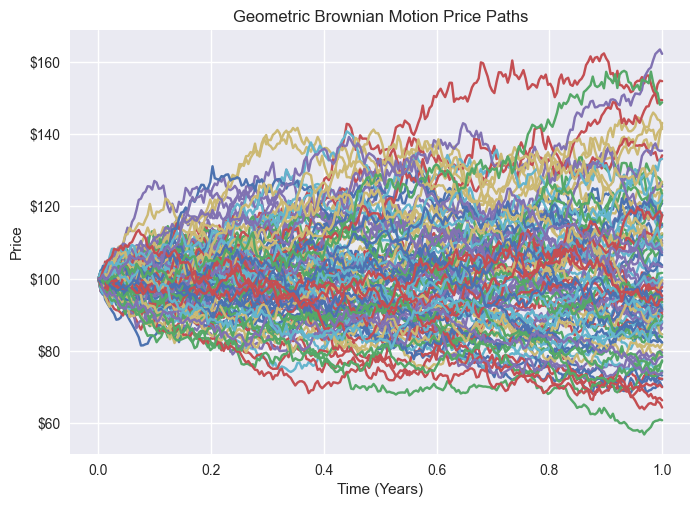

In [4]:
time_steps = np.linspace(0,T,n+1)
for path in paths:
  plt.plot(time_steps,path)

plt.grid(True)
plt.xlabel("Time (Years)")
plt.ylabel("Price")
plt.title("Geometric Brownian Motion Price Paths")
plt.gca().yaxis.set_major_formatter("${x:,.0f}")
plt.show()